In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from lokan import *
from lokan import loKAN
from lokan.nexus_plot import plot_nexus_network

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# $y = x_0 x_2 +  x_4 \sin{2 \pi x_3} + x_2$ 

In [3]:
end_range = 1.0
start_range = -1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 5) + start_range
y = x[:, 0] * x[:, 2] + torch.sin(2 * torch.pi * x[:, 3]) * x[:, 4] + x[:, 1]
dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
  
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 5]), torch.Size([1000, 1]))

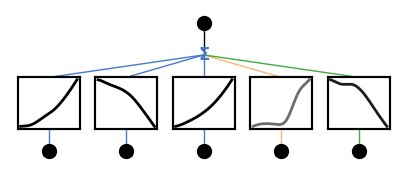

In [4]:
model = loKAN(width=[5, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [5]:
history = model.fit(dataset=dataset,
                    lr_start=0.1, lr_end=1e-3, batch_size=64, epochs=120,
                    tau_start=2.0, tau_end=0.1,
                    lamb_ent_ops_start=1e-2, lamb_ent_ops_end=1.0,
                    lamb_l1_acts=1e-3, lamb_ent_acts=1e-6,
                    update_grid=True,
                    # update_grid=False, 
                    grid_update_num=10,
                    start_grid_update_epoch=0, stop_grid_update_epoch=None,
                    refine_schedule=None,
                    verbose=10)

Epoch [  10/120]  train=0.031246  test=0.016252  tau=1.595  λ=0.0142  grid=5
Epoch [  20/120]  train=0.000917  test=0.000963  tau=1.240  λ=0.0209  grid=5
Epoch [  30/120]  train=0.000667  test=0.000909  tau=0.964  λ=0.0307  grid=5
Epoch [  40/120]  train=0.000665  test=0.000753  tau=0.749  λ=0.0452  grid=5
Epoch [  50/120]  train=0.000588  test=0.000728  tau=0.583  λ=0.0666  grid=5
Epoch [  60/120]  train=0.000564  test=0.000640  tau=0.453  λ=0.0981  grid=5
Epoch [  70/120]  train=0.000562  test=0.000662  tau=0.352  λ=0.1444  grid=5
Epoch [  80/120]  train=0.000540  test=0.000682  tau=0.274  λ=0.2127  grid=5
Epoch [  90/120]  train=0.000543  test=0.000661  tau=0.213  λ=0.3132  grid=5
Epoch [ 100/120]  train=0.000534  test=0.000654  tau=0.165  λ=0.4612  grid=5
Epoch [ 110/120]  train=0.000532  test=0.000664  tau=0.129  λ=0.6791  grid=5
Epoch [ 120/120]  train=0.000530  test=0.000656  tau=0.100  λ=1.0000  grid=5


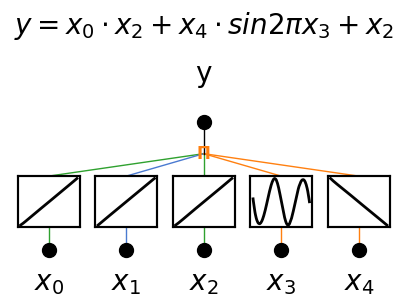

In [12]:
plot_nexus_network(
            model, 
            title=r'$y = x_0 \cdot x_2 + x_4 \cdot sin 2 \pi x_3 + x_2$',
            in_vars=[r'$x_0$', r'$x_1$', r'$x_2$', r'$x_3$', r'$x_4$'], 
            out_vars=["y"]
        )

# $y = x_0 / x_1$ 

In [13]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 2) + start_range

y = x[:, 0] / x[:, 1]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 2]), torch.Size([1000, 1]))

In [14]:
model = loKAN(width=[2, 1], grid=5, k=3, seed=42, 
                 device=device)

In [15]:
history = model.fit(dataset=dataset,
                    lr_start=0.1, lr_end=1e-3, batch_size=64, epochs=120,
                    tau_start=2.0, tau_end=0.1,
                    lamb_ent_ops_start=1e-2, lamb_ent_ops_end=1.0,
                    lamb_l1_acts=1e-3, lamb_ent_acts=1e-6,
                    update_grid=True,
                    # update_grid=False, 
                    grid_update_num=10,
                    start_grid_update_epoch=0, stop_grid_update_epoch=None,
                    refine_schedule=None,
                    verbose=10)

Epoch [  10/120]  train=0.012458  test=0.005441  tau=1.595  λ=0.0142  grid=5
Epoch [  20/120]  train=0.001521  test=0.001018  tau=1.240  λ=0.0209  grid=5
Epoch [  30/120]  train=0.000327  test=0.000260  tau=0.964  λ=0.0307  grid=5
Epoch [  40/120]  train=0.000285  test=0.000213  tau=0.749  λ=0.0452  grid=5
Epoch [  50/120]  train=0.000250  test=0.000209  tau=0.583  λ=0.0666  grid=5
Epoch [  60/120]  train=0.000273  test=0.000262  tau=0.453  λ=0.0981  grid=5
Epoch [  70/120]  train=0.000234  test=0.000216  tau=0.352  λ=0.1444  grid=5
Epoch [  80/120]  train=0.000264  test=0.000232  tau=0.274  λ=0.2127  grid=5
Epoch [  90/120]  train=0.000226  test=0.000232  tau=0.213  λ=0.3132  grid=5
Epoch [ 100/120]  train=0.000228  test=0.000227  tau=0.165  λ=0.4612  grid=5
Epoch [ 110/120]  train=0.000238  test=0.000227  tau=0.129  λ=0.6791  grid=5
Epoch [ 120/120]  train=0.000230  test=0.000228  tau=0.100  λ=1.0000  grid=5


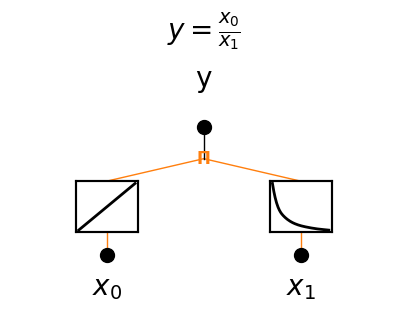

In [19]:
plot_nexus_network(
            model, 
            title=r'$y = \frac{x_0}{x_1}$',
            in_vars=[r'$x_0$', r'$x_1$'], 
            out_vars=["y"]
        )

# $y = x_0 / x_1 + x_2 / x_3$ 

In [20]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range

y = x[:, 0] / x[:, 1] + x[:, 2] / x[:, 3] 

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 4]), torch.Size([1000, 1]))

In [21]:
model = loKAN(width=[4, 1], grid=5, k=3, seed=42, 
                 device=device)

In [22]:
history = model.fit(dataset=dataset,
                    lr_start=0.1, lr_end=1e-3, batch_size=64, epochs=120,
                    tau_start=2.0, tau_end=0.1,
                    lamb_ent_ops_start=1e-2, lamb_ent_ops_end=1.0,
                    lamb_l1_acts=1e-3, lamb_ent_acts=1e-6,
                    update_grid=True,
                    # update_grid=False, 
                    grid_update_num=10,
                    start_grid_update_epoch=0, stop_grid_update_epoch=None,
                    refine_schedule=None,
                    verbose=10)

Epoch [  10/120]  train=0.072201  test=0.064229  tau=1.595  λ=0.0142  grid=5
Epoch [  20/120]  train=0.014365  test=0.015664  tau=1.240  λ=0.0209  grid=5
Epoch [  30/120]  train=0.004921  test=0.005699  tau=0.964  λ=0.0307  grid=5
Epoch [  40/120]  train=0.002149  test=0.002638  tau=0.749  λ=0.0452  grid=5
Epoch [  50/120]  train=0.001251  test=0.001655  tau=0.583  λ=0.0666  grid=5
Epoch [  60/120]  train=0.000916  test=0.001318  tau=0.453  λ=0.0981  grid=5
Epoch [  70/120]  train=0.000698  test=0.000917  tau=0.352  λ=0.1444  grid=5
Epoch [  80/120]  train=0.000657  test=0.000756  tau=0.274  λ=0.2127  grid=5
Epoch [  90/120]  train=0.000596  test=0.000731  tau=0.213  λ=0.3132  grid=5
Epoch [ 100/120]  train=0.000592  test=0.000703  tau=0.165  λ=0.4612  grid=5
Epoch [ 110/120]  train=0.000573  test=0.000686  tau=0.129  λ=0.6791  grid=5
Epoch [ 120/120]  train=0.000557  test=0.000674  tau=0.100  λ=1.0000  grid=5


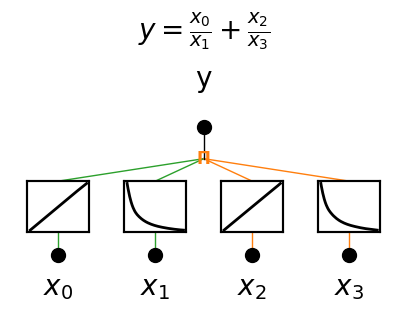

In [23]:
plot_nexus_network(
            model, 
            title=r'$y = \frac{x_0}{x_1} + \frac{x_2}{x_3}$',
            in_vars=[r'$x_0$', r'$x_1$', r'$x_2$', r'$x_3$'], 
            out_vars=["y"]
        )

# $y = x_0 x_1 + x_2 x_3$ 

In [24]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range

y = x[:, 0] * x[:, 1] + x[:, 2] * x[:, 3] 

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 4]), torch.Size([1000, 1]))

In [25]:
model = loKAN(width=[4, 1], grid=5, k=3, seed=42, 
                 device=device)

In [26]:
history = model.fit(dataset=dataset,
                    lr_start=0.1, lr_end=1e-3, batch_size=64, epochs=120,
                    tau_start=2.0, tau_end=0.1,
                    lamb_ent_ops_start=1e-2, lamb_ent_ops_end=1.0,
                    lamb_l1_acts=1e-3, lamb_ent_acts=1e-6,
                    update_grid=True,
                    # update_grid=False, 
                    grid_update_num=10,
                    start_grid_update_epoch=0, stop_grid_update_epoch=None,
                    refine_schedule=None,
                    verbose=10)

Epoch [  10/120]  train=0.005479  test=0.006068  tau=1.595  λ=0.0142  grid=5
Epoch [  20/120]  train=0.000478  test=0.000453  tau=1.240  λ=0.0209  grid=5
Epoch [  30/120]  train=0.000142  test=0.000163  tau=0.964  λ=0.0307  grid=5
Epoch [  40/120]  train=0.000057  test=0.000062  tau=0.749  λ=0.0452  grid=5
Epoch [  50/120]  train=0.000025  test=0.000030  tau=0.583  λ=0.0666  grid=5
Epoch [  60/120]  train=0.000023  test=0.000024  tau=0.453  λ=0.0981  grid=5
Epoch [  70/120]  train=0.000021  test=0.000023  tau=0.352  λ=0.1444  grid=5
Epoch [  80/120]  train=0.000020  test=0.000024  tau=0.274  λ=0.2127  grid=5
Epoch [  90/120]  train=0.000020  test=0.000023  tau=0.213  λ=0.3132  grid=5
Epoch [ 100/120]  train=0.000019  test=0.000024  tau=0.165  λ=0.4612  grid=5
Epoch [ 110/120]  train=0.000019  test=0.000024  tau=0.129  λ=0.6791  grid=5
Epoch [ 120/120]  train=0.000019  test=0.000023  tau=0.100  λ=1.0000  grid=5


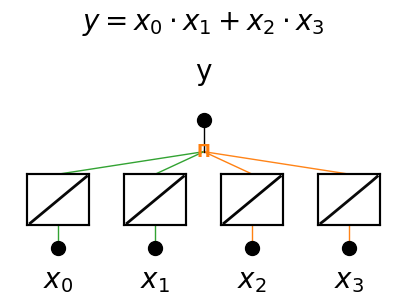

In [27]:
plot_nexus_network(
            model, 
            title=r'$y = x_0 \cdot x_1 + x_2 \cdot x_3$',
            in_vars=[r'$x_0$', r'$x_1$', r'$x_2$', r'$x_3$'], 
            out_vars=["y"]
        )

# $y = \frac{\frac{x_0}{x_1} + \frac{x_2}{x_3}}{\frac{x_4}{x_5} + \frac{x_6}{x_7}}$ 

In [32]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 8) + start_range

y = (x[:, 0] / x[:, 1] + x[:, 2] / x[:, 3]) / (x[:, 4] / x[:, 5] + x[:, 6] / x[:, 7])

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 8]), torch.Size([1000, 1]))

In [36]:
model = loKAN(width=[8, 2, 1], grid=5, k=3, seed=42, 
                 device=device)

In [37]:
history = model.fit(dataset=dataset,
                    lr_start=0.1, lr_end=1e-3, batch_size=64, epochs=120,
                    tau_start=2.0, tau_end=0.1,
                    lamb_ent_ops_start=1e-2, lamb_ent_ops_end=1.0,
                    lamb_l1_acts=1e-3, lamb_ent_acts=1e-6,
                    update_grid=True,
                    # update_grid=False, 
                    grid_update_num=10,
                    start_grid_update_epoch=0, stop_grid_update_epoch=None,
                    refine_schedule=None,
                    verbose=10)

Epoch [  10/120]  train=0.116739  test=0.165200  tau=1.595  λ=0.0142  grid=5
Epoch [  20/120]  train=0.070574  test=0.092130  tau=1.240  λ=0.0209  grid=5
Epoch [  30/120]  train=0.028623  test=0.065709  tau=0.964  λ=0.0307  grid=5
Epoch [  40/120]  train=0.029982  test=0.034269  tau=0.749  λ=0.0452  grid=5
Epoch [  50/120]  train=0.018877  test=0.029583  tau=0.583  λ=0.0666  grid=5
Epoch [  60/120]  train=0.014117  test=0.034847  tau=0.453  λ=0.0981  grid=5
Epoch [  70/120]  train=0.014441  test=0.029005  tau=0.352  λ=0.1444  grid=5
Epoch [  80/120]  train=0.014623  test=0.026761  tau=0.274  λ=0.2127  grid=5
Epoch [  90/120]  train=0.016402  test=0.025405  tau=0.213  λ=0.3132  grid=5
Epoch [ 100/120]  train=0.017097  test=0.026346  tau=0.165  λ=0.4612  grid=5
Epoch [ 110/120]  train=0.019746  test=0.033861  tau=0.129  λ=0.6791  grid=5
Epoch [ 120/120]  train=0.023053  test=0.040194  tau=0.100  λ=1.0000  grid=5


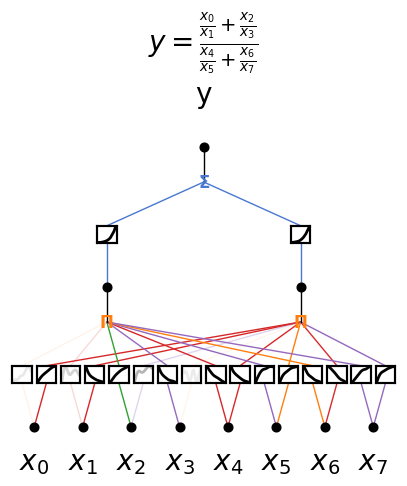

In [38]:
plot_nexus_network(
            model, 
            title=r'$y = \frac{\frac{x_0}{x_1} + \frac{x_2}{x_3}}{\frac{x_4}{x_5} + \frac{x_6}{x_7}}$',
            in_vars=[r'$x_0$', r'$x_1$', r'$x_2$', r'$x_3$', r'$x_4$', r'$x_5$', r'$x_6$', r'$x_7$'], 
            out_vars=["y"]
        )

# **Classification**

In [5]:
def _update_epoch_set(seg_start, seg_stop, n):
    window = max(seg_stop - seg_start, 1)
    freq   = max(window // n, 1)
    return {seg_start + k * freq
            for k in range(n)
            if seg_start + k * freq < seg_stop}

In [6]:
def fit_lokan_fc(
    lokan,
    fc,
    dataset,
    loss_fn,
    epochs=120,
    lr_start=0.2,
    lr_end=1e-3,
    batch_size=64,
    tau_start=2.0,
    tau_end=0.1,
    lamb_ent_ops_start=1e-2,
    lamb_ent_ops_end=1.0,
    lamb_l1_acts=1e-3,
    lamb_ent_acts=1e-6,
    update_grid=True,
    grid_update_num=10,
    refine_schedule=None,
    verbose=0,
):
    """Train LOKAN feature extractor + arbitrary FC head jointly.

    The training loop is identical to LOKAN.fit() except:
      - The optimizer includes both lokan.parameters() and fc.parameters().
      - The task loss comes from loss_fn(fc(lokan(x)), y) instead of MSE.
      - Regularization (entropy on logits, L1+entropy on spline scales) is
        computed only from LOKAN layers — FC is trained only via task loss.

    Returns epoch_metric: list[float], one value per epoch (evaluated on
    the full test set using the task loss, converted to accuracy when the
    output is binary classification).
    """
    refine_dict = dict(refine_schedule) if refine_schedule else {}

    if update_grid:
        if refine_dict:
            boundaries   = [0] + sorted(refine_dict) + [epochs]
            _update_epochs = set()
            for seg_s, seg_e in zip(boundaries, boundaries[1:]):
                half = seg_s + (seg_e - seg_s) // 2
                _update_epochs |= _update_epoch_set(seg_s, half, grid_update_num)
        else:
            _update_epochs = _update_epoch_set(0, epochs // 2, grid_update_num)
    else:
        _update_epochs = set()

    # Pre-fit grid to data distribution
    with torch.no_grad():
        lokan.update_grid(dataset['train_input'])

    all_params = list(lokan.parameters()) + list(fc.parameters())
    optimizer  = optim.Adam(all_params, lr=lr_start)
    epoch_acc  = []

    for epoch in range(epochs):
        t = epoch / max(epochs - 1, 1)

        # Inline grid refinement
        if epoch in refine_dict:
            new_g     = refine_dict[epoch]
            model_new = LOKAN(
                width=[list(w) for w in lokan.width],
                grid=new_g, k=lokan.k,
                base_fun=lokan.base_fun_name,
                symbolic_enabled=lokan.symbolic_enabled,
                affine_trainable=lokan.affine_trainable,
                grid_eps=lokan.grid_eps,
                grid_range=lokan.grid_range,
                sp_trainable=lokan.sp_trainable,
                sb_trainable=lokan.sb_trainable,
                save_act=lokan.save_act,
                device=lokan.device,
            )
            model_new.initialize_from_another_model(lokan, lokan.cache_data)
            lokan.act_fun = model_new.act_fun
            lokan.grid    = new_g
            cur_lr        = lr_start * (lr_end / lr_start) ** t
            all_params    = list(lokan.parameters()) + list(fc.parameters())
            optimizer     = optim.Adam(all_params, lr=cur_lr)
            if verbose:
                print(f'  [refine] epoch {epoch}: grid → {new_g}')

        # Exponential schedules
        new_lr   = lr_start           * (lr_end           / lr_start)           ** t
        new_tau  = tau_start          * (tau_end          / tau_start)          ** t
        new_lamb = lamb_ent_ops_start * (lamb_ent_ops_end / lamb_ent_ops_start) ** t

        for pg in optimizer.param_groups:
            pg['lr'] = new_lr
        for m in lokan.modules():
            if isinstance(m, LOKANLayer):
                m.tau = new_tau

        # Adaptive grid update
        if epoch in _update_epochs:
            with torch.no_grad():
                lokan.update_grid(dataset['train_input'])

        # Mini-batch loop
        n_train          = dataset['train_input'].shape[0]
        perm             = torch.randperm(n_train)
        train_loss_epoch = 0.0
        n_batches        = 0

        for start in range(0, n_train, batch_size):
            idx     = perm[start:start + batch_size]
            batch_x = dataset['train_input'][idx]
            batch_y = dataset['train_label'][idx]

            out        = fc(lokan(batch_x))
            task_loss  = loss_fn(out, batch_y)

            # Entropy regularization on operation logits (LOKAN only)
            ent_ops, n_ops = 0.0, 0
            for m in lokan.modules():
                if isinstance(m, LOKANLayer):
                    probs    = torch.softmax(m.logits / m.tau, dim=-1)
                    ent_ops += (-probs * torch.log(probs + 1e-8)).sum(dim=-1).mean()
                    n_ops   += 1
            ent_ops_avg = ent_ops / n_ops if n_ops else 0.0

            # Sparsity regularization on spline activations (LOKAN only)
            l1_acts, ent_acts, n_al = 0.0, 0.0, 0
            for acts in lokan.acts_scale_spline:
                l1_acts += torch.sum(acts)
                p_row    = acts / (acts.sum(dim=1, keepdim=True) + 1e-8)
                p_col    = acts / (acts.sum(dim=0, keepdim=True) + 1e-8)
                ent_acts += (
                    -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                    - torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                )
                n_al += 1
            l1_acts  = l1_acts  / n_al if n_al else 0.0
            ent_acts = ent_acts / n_al if n_al else 0.0

            total = (task_loss
                     + new_lamb      * ent_ops_avg
                     + lamb_l1_acts  * l1_acts
                     + lamb_ent_acts * ent_acts)

            optimizer.zero_grad()
            total.backward()
            optimizer.step()

            train_loss_epoch += task_loss.item()
            n_batches        += 1

        train_loss_epoch /= n_batches

        # Per-epoch accuracy on test set
        with torch.no_grad():
            pred = fc(lokan(dataset['test_input']))
            acc  = ((pred > 0.5).float() == dataset['test_label']).float().mean().item()
            epoch_acc.append(acc)

        if verbose and (epoch + 1) % verbose == 0:
            print(
                f'Epoch [{epoch+1:4d}/{epochs}]  '
                f'train={train_loss_epoch:.6f}  test_acc={acc:.4f}  '
                f'tau={new_tau:.3f}  λ={new_lamb:.4f}  grid={lokan.grid}'
            )

    # Populate acts_scale_spline for interpretability probe
    with torch.no_grad():
        lokan(dataset['train_input'])

    return epoch_acc

# $y = \frac{x_0}{x_1} + \frac{x_2}{x_3} > 2.2$ 

In [105]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range

y = x[:, 0] / x[:, 1] + x[:, 2] / x[:, 3]
y_class = (y > 2.2).float()

dataset = {
    'train_input': x[:1000],
    'train_label': y_class[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y_class[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
print(dataset['train_input'].shape, dataset['train_label'].shape)
print(np.unique(y_class, return_counts=True))

torch.Size([1000, 4]) torch.Size([1000, 1])
(array([0., 1.], dtype=float32), array([563, 637]))


In [82]:
lokan = loKAN(
    width=[4, 1], grid=3, k=3,
    grid_range=[0.1, 1.0], device=device,
)
fc = nn.Sequential(nn.Linear(1, 1), nn.Sigmoid()).to(device)
bce = nn.BCELoss()

In [83]:
# refine = [(40, 5), (80, 10)]
refine = None

In [84]:
acc_curve = fit_lokan_fc(
    lokan, fc, 
    dataset=dataset,
    loss_fn=lambda out, y: bce(out, y),
    epochs=120,
    refine_schedule=refine,
    update_grid=True, grid_update_num=10,
    verbose=10
)

Epoch [  10/120]  train=0.132838  test_acc=0.9350  tau=1.595  λ=0.0142  grid=3
Epoch [  20/120]  train=0.096176  test_acc=0.9500  tau=1.240  λ=0.0209  grid=3
Epoch [  30/120]  train=0.087309  test_acc=0.9750  tau=0.964  λ=0.0307  grid=3
Epoch [  40/120]  train=0.078220  test_acc=0.9800  tau=0.749  λ=0.0452  grid=3
Epoch [  50/120]  train=0.081675  test_acc=0.9800  tau=0.583  λ=0.0666  grid=3
Epoch [  60/120]  train=0.070702  test_acc=0.9800  tau=0.453  λ=0.0981  grid=3
Epoch [  70/120]  train=0.066251  test_acc=0.9800  tau=0.352  λ=0.1444  grid=3
Epoch [  80/120]  train=0.065031  test_acc=0.9800  tau=0.274  λ=0.2127  grid=3
Epoch [  90/120]  train=0.062498  test_acc=0.9850  tau=0.213  λ=0.3132  grid=3
Epoch [ 100/120]  train=0.063369  test_acc=0.9800  tau=0.165  λ=0.4612  grid=3
Epoch [ 110/120]  train=0.062352  test_acc=0.9800  tau=0.129  λ=0.6791  grid=3
Epoch [ 120/120]  train=0.062377  test_acc=0.9800  tau=0.100  λ=1.0000  grid=3


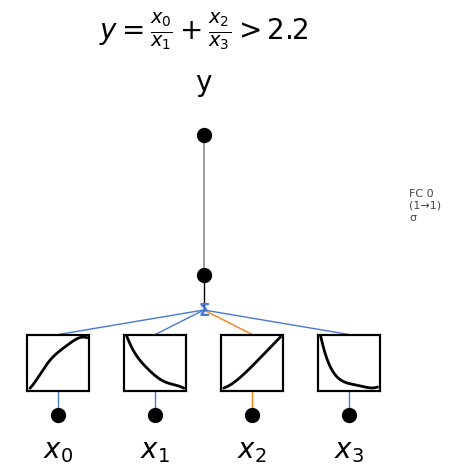

In [86]:
plot_nexus_network(
            lokan, 
            fc,
            title=r'$y = \frac{x_0}{x_1} + \frac{x_2}{x_3} > 2.2$',
            in_vars=[r'$x_0$', r'$x_1$', r'$x_2$', r'$x_3$'], 
            out_vars=["y"]
        )

# $y = (x_0 + x_1) \cdot (x_2 + x_3)$ 

In [113]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range

y = (x[:, 0] + x[:, 1]) * (x[:, 2] + x[:, 3])
y_class = (y > 1.1).float()

dataset = {
    'train_input': x[:1000],
    'train_label': y_class[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y_class[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
print(dataset['train_input'].shape, dataset['train_label'].shape)
print(np.unique(y_class, return_counts=True))

torch.Size([1000, 4]) torch.Size([1000, 1])
(array([0., 1.], dtype=float32), array([592, 608]))


In [114]:
lokan = loKAN(
    width=[4, 2], grid=5, k=3,
    grid_range=[0.1, 1.0], device=device,
)
fc = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid()).to(device)
bce = nn.BCELoss()

In [115]:
acc_curve = fit_lokan_fc(
    lokan, fc, 
    dataset=dataset,
    loss_fn=lambda out, y: bce(out, y),
    epochs=120,
    refine_schedule=None,
    update_grid=True, grid_update_num=10,
    verbose=10
)

Epoch [  10/120]  train=0.072107  test_acc=0.9400  tau=1.595  λ=0.0142  grid=5
Epoch [  20/120]  train=0.044265  test_acc=0.9400  tau=1.240  λ=0.0209  grid=5
Epoch [  30/120]  train=0.054850  test_acc=0.9700  tau=0.964  λ=0.0307  grid=5
Epoch [  40/120]  train=0.049659  test_acc=0.9600  tau=0.749  λ=0.0452  grid=5
Epoch [  50/120]  train=0.025574  test_acc=0.9700  tau=0.583  λ=0.0666  grid=5
Epoch [  60/120]  train=0.027163  test_acc=0.9650  tau=0.453  λ=0.0981  grid=5
Epoch [  70/120]  train=0.021346  test_acc=0.9700  tau=0.352  λ=0.1444  grid=5
Epoch [  80/120]  train=0.021012  test_acc=0.9750  tau=0.274  λ=0.2127  grid=5
Epoch [  90/120]  train=0.021012  test_acc=0.9700  tau=0.213  λ=0.3132  grid=5
Epoch [ 100/120]  train=0.019867  test_acc=0.9700  tau=0.165  λ=0.4612  grid=5
Epoch [ 110/120]  train=0.018852  test_acc=0.9700  tau=0.129  λ=0.6791  grid=5
Epoch [ 120/120]  train=0.019837  test_acc=0.9750  tau=0.100  λ=1.0000  grid=5


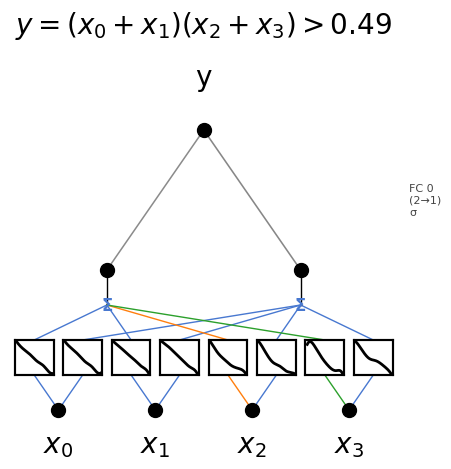

In [116]:
plot_nexus_network(
            lokan, 
            fc,
            title=r'$y = (x_0 + x_1)(x_2 + x_3) > 0.49$',
            in_vars=[r'$x_0$', r'$x_1$', r'$x_2$', r'$x_3$'], 
            out_vars=["y"]
        )

## $y = sin 2 \pi x_0 + sin 2 \pi x_0$

In [109]:
end_range = 1.0
start_range = -1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range

y = torch.sin(2 * torch.pi * x[:, 0]) + torch.sin(2 * torch.pi * x[:, 1])
y_class = (y > 0.0).float()

dataset = {
    'train_input': x[:1000],
    'train_label': y_class[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y_class[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
print(dataset['train_input'].shape, dataset['train_label'].shape)
print(np.unique(y_class, return_counts=True))

torch.Size([1000, 4]) torch.Size([1000, 1])
(array([0., 1.], dtype=float32), array([610, 590]))


In [110]:
lokan = loKAN(
    width=[2, 1], grid=5, k=3,
    grid_range=[0.1, 1.0], device=device,
)
fc = nn.Sequential(nn.Linear(1, 1), nn.Sigmoid()).to(device)
bce = nn.BCELoss()

In [111]:
acc_curve = fit_lokan_fc(
    lokan, fc, 
    dataset=dataset,
    loss_fn=lambda out, y: bce(out, y),
    epochs=120,
    refine_schedule=None,
    update_grid=True, grid_update_num=10,
    verbose=10
)

Epoch [  10/120]  train=0.097819  test_acc=0.9450  tau=1.595  λ=0.0142  grid=5
Epoch [  20/120]  train=0.104352  test_acc=0.9450  tau=1.240  λ=0.0209  grid=5
Epoch [  30/120]  train=0.072334  test_acc=0.9550  tau=0.964  λ=0.0307  grid=5
Epoch [  40/120]  train=0.075262  test_acc=0.9600  tau=0.749  λ=0.0452  grid=5
Epoch [  50/120]  train=0.064059  test_acc=0.9600  tau=0.583  λ=0.0666  grid=5
Epoch [  60/120]  train=0.063628  test_acc=0.9600  tau=0.453  λ=0.0981  grid=5
Epoch [  70/120]  train=0.062221  test_acc=0.9550  tau=0.352  λ=0.1444  grid=5
Epoch [  80/120]  train=0.057880  test_acc=0.9600  tau=0.274  λ=0.2127  grid=5
Epoch [  90/120]  train=0.059593  test_acc=0.9550  tau=0.213  λ=0.3132  grid=5
Epoch [ 100/120]  train=0.058230  test_acc=0.9600  tau=0.165  λ=0.4612  grid=5
Epoch [ 110/120]  train=0.058965  test_acc=0.9600  tau=0.129  λ=0.6791  grid=5
Epoch [ 120/120]  train=0.059330  test_acc=0.9600  tau=0.100  λ=1.0000  grid=5


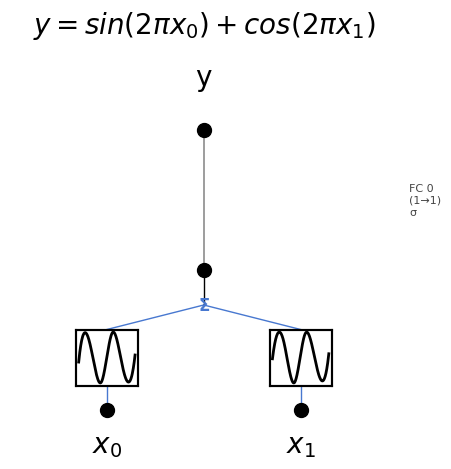

In [112]:
plot_nexus_network(
            lokan, 
            fc,
            title=r'$y = sin(2 \pi x_0) + cos(2 \pi x_1)$',
            in_vars=[r'$x_0$', r'$x_1$'], 
            out_vars=["y"]
        )

## $y = sin (2 \pi x_0) + \frac{1}{1.5 + x_1} + x_2^2$

In [97]:
end_range = 1.0
start_range = -1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 3) + start_range

y = torch.sin(2 * torch.pi * x[:, 0]) + (1/(1.5+x[:, 1])) + x[:, 2] * x[:, 2]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
print(dataset['train_input'].shape, dataset['train_label'].shape)

torch.Size([1000, 3]) torch.Size([1000, 1])


In [105]:
lokan = loKAN(
    width=[3, 3], grid=5, k=3,
    grid_range=[0.1, 1.0], device=device,
)
fc = nn.Sequential(
    nn.Linear(3, 4), nn.SiLU(),
    nn.Linear(4, 1)
).to(device)
mse = nn.MSELoss()

In [106]:
_ = fit_lokan_fc(
    lokan, fc, 
    dataset=dataset,
    loss_fn=lambda out, y: mse(out, y),
    epochs=120,
    lamb_l1_acts = 1e-3,
    lamb_ent_acts = 1e-6,
    refine_schedule=None,
    update_grid=True, grid_update_num=10,
    verbose=10
)

Epoch [  10/120]  train=0.002740  test_acc=0.0000  tau=1.595  λ=0.0142  grid=5
Epoch [  20/120]  train=0.001967  test_acc=0.0000  tau=1.240  λ=0.0209  grid=5
Epoch [  30/120]  train=0.002278  test_acc=0.0000  tau=0.964  λ=0.0307  grid=5
Epoch [  40/120]  train=0.002022  test_acc=0.0000  tau=0.749  λ=0.0452  grid=5
Epoch [  50/120]  train=0.001886  test_acc=0.0000  tau=0.583  λ=0.0666  grid=5
Epoch [  60/120]  train=0.001783  test_acc=0.0000  tau=0.453  λ=0.0981  grid=5
Epoch [  70/120]  train=0.001776  test_acc=0.0000  tau=0.352  λ=0.1444  grid=5
Epoch [  80/120]  train=0.001672  test_acc=0.0000  tau=0.274  λ=0.2127  grid=5
Epoch [  90/120]  train=0.001652  test_acc=0.0000  tau=0.213  λ=0.3132  grid=5
Epoch [ 100/120]  train=0.001652  test_acc=0.0000  tau=0.165  λ=0.4612  grid=5
Epoch [ 110/120]  train=0.001647  test_acc=0.0000  tau=0.129  λ=0.6791  grid=5
Epoch [ 120/120]  train=0.001608  test_acc=0.0000  tau=0.100  λ=1.0000  grid=5


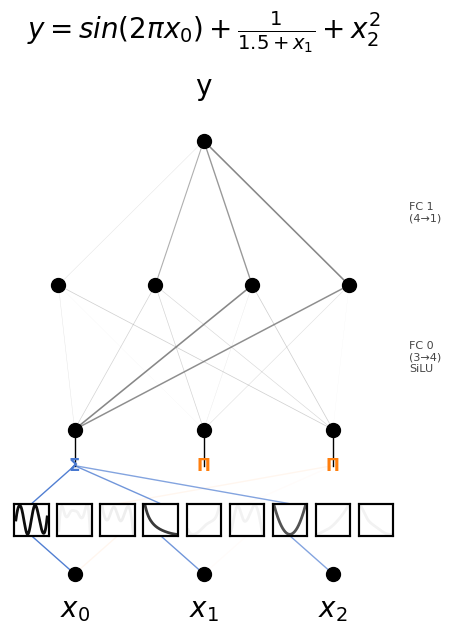

In [108]:
plot_nexus_network(
            lokan, 
            fc,
            title=r'$y = sin (2 \pi x_0) + \frac{1}{1.5 + x_1} + x_2^2$',
            in_vars=[r'$x_0$', r'$x_1$', r'$x_2$'], 
            out_vars=["y"]
        )